#### CNN을 이용한 figers 이미지 분류

In [20]:
import glob
import numpy as np
from PIL import Image
train_images = glob.glob('data/fingers/train/*.png')
test_images = glob.glob('data/fingers/test/*.png')

print(np.shape(train_images))
print(np.shape(test_images))

(18000,)
(3600,)


In [21]:
train_input = []
train_target = []
test_input = []
test_target = []

for i in sorted(train_images):
  img = Image.open(i)
  imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
  train_input.append(imgResize)
  train_target.append(i[-6:-4])

for i in sorted(test_images):
  img = Image.open(i)
  imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
  test_input.append(imgResize)
  test_target.append(i[-6:-4])

In [22]:
# train_data 만들기
tempData = np.zeros(
    18000*32*32,
    dtype=np.int32
).reshape(18000, 32, 32)
tempData.shape

i = 0
for image in train_input:
 img = np.array(image, dtype=np.int32)
 tempData[i,:,:] = image
 i += 1

train_input = tempData.copy()

In [23]:
# test_data 만들기
tempData = np.zeros(
    3600*32*32,
    dtype=np.int32
).reshape(3600, 32, 32)
tempData.shape

i = 0
for image in test_input:
 img = np.array(image, dtype=np.int32)
 tempData[i,:,:] = image
 i += 1

test_input = tempData.copy()

In [24]:
print(train_input.shape)
print(test_input.shape)

(18000, 32, 32)
(3600, 32, 32)


In [25]:
#['0L' '0R' '1L' '1R' '2L' '2R' '3L' '3R' '4L' '4R' '5L' '5R']
label_to_int = {
    '0R': 0,
    '1R': 1,
    '2R': 2,
    '3R': 3,
    '4R': 4,
    '5R': 5,
    '0L': 6,
    '1L': 7,
    '2L': 8,
    '3L': 9,
    '4L': 10,
    '5L': 11
}

In [26]:
# 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()
train_target = np.array(train_target)

temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()
test_target = np.array(test_target)

In [27]:
# train과 valid data 분리
from sklearn.model_selection import train_test_split

train_scaled = train_input.reshape(-1, 32, 32, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = \
	train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
	)
# 데이터 개수가 둘 다 14400으로 똑같이 찍히는지 확인!
print("학습 이미지 개수:", train_scaled.shape[0])
print("학습 라벨 개수:", train_target.shape[0])

학습 이미지 개수: 14400
학습 라벨 개수: 14400


In [35]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu',padding='same', input_shape=(32, 32, 1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu',padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu',padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dropout(0.5))  # 과적합 방지용 (선택)
model.add(keras.layers.Dense(12, activation='softmax')) # 이진분류만 SIGMOID

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,636 (619.67 KB)

 Trainable params: 158,636 (619.67 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_figers_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
) 

history= model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8301 - loss: 0.3995 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8728 - loss: 0.3035 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9010 - loss: 0.2651 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9016 - loss: 0.2591 - val_accuracy: 1.0000 - val_loss: 2.9257e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9186 - loss: 0.2172 - val_accuracy: 1.0000 - val_loss: 3.7965e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9218 - loss: 0.2061 - val_accuracy: 1.0000 - val_loss: 6.5344e-04


In [45]:
model = keras.models.load_model('data/best_figers_model.keras')
print('train: ',model.evaluate(train_scaled, train_target))
print('valid: ', model.evaluate(val_scaled, val_target))
print('test: ', model.evaluate(test_input, test_target))

450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 5.4253e-04
train:  [0.0005425304407253861, 1.0]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.5344e-04
valid:  [0.000653441995382309, 1.0]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9967 - loss: 1.3341
test:  [1.3340550661087036, 0.996666669845581]


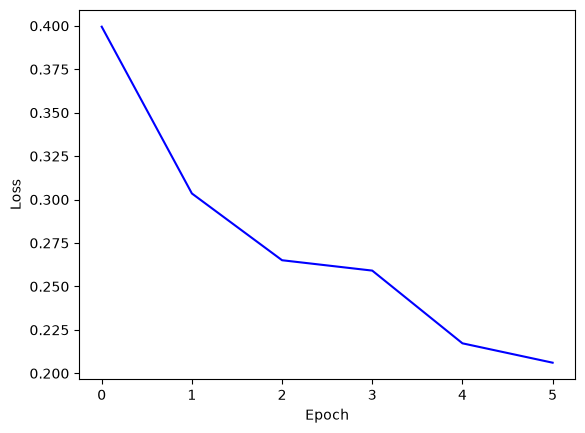

In [46]:
import matplotlib.pyplot as plt
# history의 시각화
plt.plot(history.history['loss'], color='blue')
# plt.plot(history.history['val_loss'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()